C:\Users\combj\AppData\Local\Temp\ipykernel_16872\2292848432.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Fail' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df2.loc[i, 'Failed?'] = 'Fail'


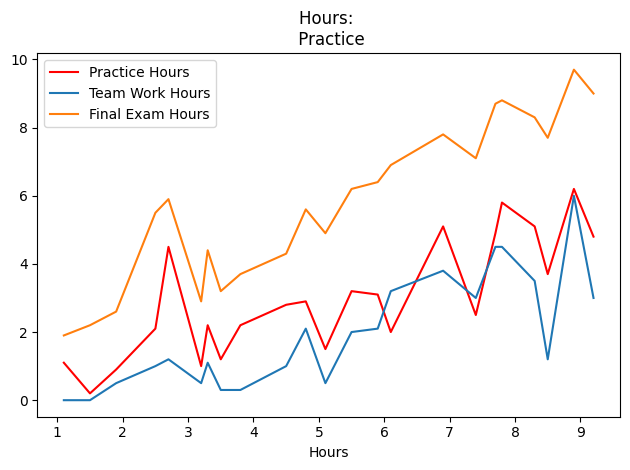

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Student_Grades.csv')
balls = df.to_numpy() # useful to get something using normal python
df.T # swaps rows and columns axis
df.sort_index(axis=1, ascending=True) # sort by columns
df.sort_values(by='Scores') # sort by values in a column

df[['Scores']] # get a column from the dataframe
df[['Scores', 'Hours', 'Grade']] # get multiple columns from the dataframe
df.loc[:, ['Scores']] # gets everything in the column 'Scores'
df.iloc[:, [5]] # gets everything in the column 'Scores'


df.iloc[:, [5]] # gets everything in the column 'Scores'

item = df.loc[0, 'Scores'] # gets the max value in the column
for i in range(1, len(df)): 
    if df.loc[i, 'Scores'] > item:
        item = df.loc[i, 'Scores'] 

df.iloc[[0], [0]] # gets the value at the first row and first column
df.iat[0, 0] # gets the value at the first row and first column
df.iloc[1:3, :] # doesnt take another squared brackets when slicing

df[df['Scores'] > 50] # get all rows where Scores > 50
df[(df['Scores'] > 50) & (df['Scores'] < 70)] # get all rows where 50 < Scores < 70

df2 = df.copy()
df2['Failed?'] = df2['Scores'] > 50 # new column with boolean values

for i in range(len(df2)): # convert boolean values to strings
    if df2.loc[i, 'Failed?'] == True:
        df2.loc[i, 'Failed?'] = 'Pass'
    else:
        df2.loc[i, 'Failed?'] = 'Fail'

balls = df['Scores'].iloc[:10] # get the top 10 most common values in the column
# balls.plot.hist(x='Scores') # plot the top 10 most common values in the column
# df['Grade'].value_counts().plot(kind='bar') # plot the frequency of each value in the column
# df['Grade'].value_counts().plot(kind='barh') # plot the frequency of each value in the column
# df['MidTerm'].value_counts().plot(kind='pie') # plot the frequency of each value in the column
# df.plot.hist(y='Scores')
# ax = df.plot.line(y='Scores', alpha=0.5)
# ax.figure.savefig('histogram.png')

df[df['Scores'].notna()]
df.dropna() # drop rows with NaN values
df.sort_values(by='Scores', ascending=False) # dataframe sorted by Scores in descending order
df['Scores'].sort_values(ascending=False) # series sorted by Scores in descending order

df.groupby('Grade').value_counts() # group by Grade and get the mean of each group
ag = df.groupby('Grade').count()
ag[['Hours']]
af = df.groupby('Hours')['Practice'].count().sort_values(ascending=False)
# df.groupby('Hours')['Practice'].count().sort_values(ascending=False)\
# .plot(kind='bar', title='Hours: \n Practice', color='red')

total = df.groupby('Hours')['Practice'].sum()
total2 = df.groupby('Hours')['TeamWork'].sum()
total3 = df.groupby('Hours')['FinalExam'].sum()
de = total.plot(title='Hours: \n Practice', color='red', legend=True, label='Practice Hours')
dt = total2.plot(ax=de, legend=True, label='Team Work Hours')
ax = total3.plot(ax=dt, legend=True, label='Final Exam Hours')
plt.tight_layout()
ax.figure.savefig('line.png')


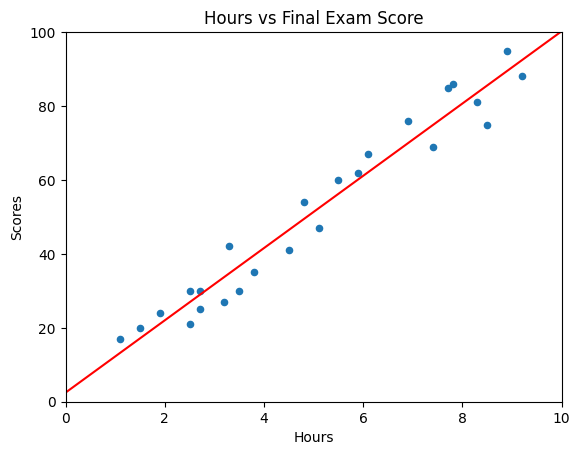

,Hours,Practice,TeamWork,MidTerm,FinalExam,FinalGradeScore,Grade
0,2.5,0.5,0.0,2.0,2.3,21.0,C
1,5.1,1.5,0.5,4.0,4.9,47.0,B
2,3.2,1.0,0.5,3.0,2.9,27.0,C
3,8.5,3.7,1.2,7.0,7.7,75.0,A
4,3.5,1.2,0.3,3.0,3.2,30.0,C
5,1.5,0.2,0.0,2.0,2.2,20.0,C
6,9.2,4.8,3.0,8.0,9.0,88.0,A
7,5.5,3.2,2.0,6.0,6.2,60.0,B
8,8.3,5.1,3.5,8.0,8.3,81.0,A
9,2.7,1.5,0.0,3.0,2.7,25.0,C


In [2]:
df.fillna('some guy didn\'t take the test') # fill all NaN values with a string
df.plot(kind='scatter', x='Hours', y='Scores')
plt.ylim(0, 100)
plt.xlim(0, 10)
plt.title("Hours vs Final Exam Score")

df = df.dropna()
ypoints = df['Scores'].to_numpy()
xpoints = df['Hours'].to_numpy()

plt.scatter(xpoints, ypoints, s = 8)
b, a = np.polyfit(xpoints, ypoints, deg = 1)    # b is slope, a is the intercept
xseq = np.linspace(0, 10)   # try (5, 9) to get only a portion of the fit
plt.plot(xseq, a + b * xseq, c = 'red') # a + b*xseq is the equation of line of best fit 
plt.show()

df.rename(columns={'Scores': 'FinalGradeScore'}) # rename a column


In [3]:
df[['Hours']].sample(10)
df[['MidTerm', 'FinalExam']].sample(10)
ae = df.dropna()
ae = ae[['Scores']].sample(10)
ae['Grade'] = ''

for i in range(len(ae)):
    grade = ae.iloc[i, 0]
    if grade < 60:
        ae.iloc[i, 1] = 'F'
    elif grade < 70:
        ae.iloc[i, 1] = 'C'
    elif grade < 80:
        ae.iloc[i, 1] = 'B'
    else:
        ae.iloc[i, 1] = 'A'

ae


,Scores,Grade
14,17.0,F
3,75.0,B
16,30.0,F
12,41.0,F
8,81.0,A
21,54.0,F
18,67.0,C
10,85.0,A
4,30.0,F
5,20.0,F
